R Lab 3: Multi-Source Retail Sales Data Integration and Analysis

---

Name: Aditi Gawari
Roll no: 23102A0025
CMPN A

In [1]:
install.packages(c(
  "tidyverse",
  "readxl",
  "jsonlite",
  "DBI",
  "RSQLite",
  "lubridate"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(tidyverse)
library(readxl)
library(jsonlite)
library(DBI)
library(RSQLite)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten




In [3]:
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

download.file(
  url,
  destfile = "Online_Retail.xlsx",
  mode = "wb"
)

file.exists("Online_Retail.xlsx")

[1] TRUE

In [4]:
retail_raw <- read_excel("Online_Retail.xlsx")

In [5]:
head(retail_raw)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


In [6]:
str(retail_raw)

tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


In [7]:
dim(retail_raw)

[1] 541909      8

In [8]:
transactions <- retail_raw %>%
  select(
    InvoiceNo,
    StockCode,
    CustomerID,
    Quantity,
    InvoiceDate
  )

write_csv(transactions, "transactions.csv")

In [10]:
head(transactions)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate
<chr>,<chr>,<dbl>,<dbl>,<dttm>
536365,85123A,17850,6,2010-12-01 08:26:00
536365,71053,17850,6,2010-12-01 08:26:00
536365,84406B,17850,8,2010-12-01 08:26:00
536365,84029G,17850,6,2010-12-01 08:26:00
536365,84029E,17850,6,2010-12-01 08:26:00
536365,22752,17850,2,2010-12-01 08:26:00


In [11]:
products <- retail_raw %>%
  select(
    StockCode,
    Description,
    UnitPrice
  ) %>%
  distinct(StockCode, .keep_all = TRUE)

In [12]:
head(products)

StockCode,Description,UnitPrice
<chr>,<chr>,<dbl>
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.55
71053,WHITE METAL LANTERN,3.39
84406B,CREAM CUPID HEARTS COAT HANGER,2.75
84029G,KNITTED UNION FLAG HOT WATER BOTTLE,3.39
84029E,RED WOOLLY HOTTIE WHITE HEART.,3.39
22752,SET 7 BABUSHKA NESTING BOXES,7.65


In [13]:
write_json(
  products,
  "products.json",
  pretty = TRUE,
  na = "null"
)

In [14]:
file.exists("products.json")

[1] TRUE

In [15]:
customers <- retail_raw %>%
  select(
    CustomerID,
    Country
  ) %>%
  distinct(CustomerID, .keep_all = TRUE)

In [18]:
install.packages("writexl")
library(writexl)

write_xlsx(
  customers,
  "customers.xlsx"
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [19]:
file.exists("customers.xlsx")

[1] TRUE

In [20]:
list.files()

[1] "customers.xlsx"     "Online_Retail.xlsx" "products.json"     
[4] "sample_data"        "transactions.csv"

TASK 1 — Import and Clean the Data

In [21]:
transactions_imported <- read_csv(
  "transactions.csv",
  show_col_types = FALSE
)

In [22]:
head(transactions_imported)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate
<chr>,<chr>,<dbl>,<dbl>,<dttm>
536365,85123A,17850,6,2010-12-01 08:26:00
536365,71053,17850,6,2010-12-01 08:26:00
536365,84406B,17850,8,2010-12-01 08:26:00
536365,84029G,17850,6,2010-12-01 08:26:00
536365,84029E,17850,6,2010-12-01 08:26:00
536365,22752,17850,2,2010-12-01 08:26:00


In [23]:
str(transactions_imported)

spc_tbl_ [541,909 × 5] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 - attr(*, "spec")=
  .. cols(
  ..   InvoiceNo = col_character(),
  ..   StockCode = col_character(),
  ..   CustomerID = col_double(),
  ..   Quantity = col_double(),
  ..   InvoiceDate = col_datetime(format = "")
  .. )
 - attr(*, "problems")=<pointer: 0x5895edba5030> 


In [24]:
dim(transactions_imported)

[1] 541909      5

In [25]:
products_imported <- fromJSON(
  "products.json"
)

In [26]:
head(products_imported)

,StockCode,Description,UnitPrice
,<chr>,<chr>,<dbl>
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.55
2,71053,WHITE METAL LANTERN,3.39
3,84406B,CREAM CUPID HEARTS COAT HANGER,2.75
4,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,3.39
5,84029E,RED WOOLLY HOTTIE WHITE HEART.,3.39
6,22752,SET 7 BABUSHKA NESTING BOXES,7.65


In [27]:
str(products_imported)

'data.frame':	4070 obs. of  3 variables:
 $ StockCode  : chr  "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr  "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ UnitPrice  : num  2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...


In [28]:
customers_imported <- read_excel(
  "customers.xlsx"
)

In [29]:
head(customers_imported)

CustomerID,Country
<dbl>,<chr>
17850,United Kingdom
13047,United Kingdom
12583,France
13748,United Kingdom
15100,United Kingdom
15291,United Kingdom


Missing Values

In [30]:
colSums(is.na(transactions_imported))

InvoiceNo   StockCode  CustomerID    Quantity InvoiceDate 
          0           0      135080           0           0

In [31]:
colSums(is.na(products_imported))

StockCode Description   UnitPrice 
          0         176           0

In [32]:
colSums(is.na(customers_imported))

CustomerID    Country 
         1          0

In [33]:
transactions_clean <- transactions_imported %>%
  filter(!is.na(CustomerID))

In [34]:
products_clean <- products_imported %>%
  filter(
    !is.na(StockCode),
    !is.na(Description),
    !is.na(UnitPrice)
  )

In [35]:
customers_clean <- customers_imported %>%
  filter(
    !is.na(CustomerID),
    !is.na(Country)
  )

Duplicate records

In [36]:
transactions_clean <- transactions_clean %>%
  distinct()

In [37]:
products_clean <- products_clean %>%
  distinct(StockCode, .keep_all = TRUE)

In [38]:
customers_clean <- customers_clean %>%
  distinct(CustomerID, .keep_all = TRUE)

In [39]:
sum(duplicated(transactions_clean))

[1] 0

In [40]:
sum(duplicated(products_clean))

[1] 0

In [41]:
sum(duplicated(customers_clean))

[1] 0

Removing Invalid Quantites

In [42]:
transactions_clean <- transactions_clean %>%
  filter(Quantity > 0)

In [44]:
summary(transactions_clean$Quantity)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    1.00     2.00     6.00    13.15    12.00 80995.00 

In [46]:
sum(transactions_clean$Quantity <= 0)

[1] 0

In [47]:
products_clean <- products_clean %>%
  filter(UnitPrice > 0)

In [49]:
summary(products_clean$UnitPrice)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    0.001     1.250     2.510     7.290     4.950 11062.060 

In [50]:
sum(products_clean$UnitPrice <= 0)

[1] 0

TASK 2 — Integrate Multiple Data Sources

Join transactions with products

In [51]:
sales_integrated <- transactions_clean %>%
  left_join(
    products_clean,
    by = "StockCode"
  )

In [52]:
head(sales_integrated)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice
<chr>,<chr>,<dbl>,<dbl>,<dttm>,<chr>,<dbl>
536365,85123A,17850,6,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,2.55
536365,71053,17850,6,2010-12-01 08:26:00,WHITE METAL LANTERN,3.39
536365,84406B,17850,8,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,2.75
536365,84029G,17850,6,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,3.39
536365,84029E,17850,6,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,3.39
536365,22752,17850,2,2010-12-01 08:26:00,SET 7 BABUSHKA NESTING BOXES,7.65


Join with customers

In [53]:
sales_integrated <- sales_integrated %>%
  left_join(
    customers_clean,
    by = "CustomerID"
  )

In [54]:
head(sales_integrated)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Country
<chr>,<chr>,<dbl>,<dbl>,<dttm>,<chr>,<dbl>,<chr>
536365,85123A,17850,6,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,2.55,United Kingdom
536365,71053,17850,6,2010-12-01 08:26:00,WHITE METAL LANTERN,3.39,United Kingdom
536365,84406B,17850,8,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,2.75,United Kingdom
536365,84029G,17850,6,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,United Kingdom
536365,84029E,17850,6,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,3.39,United Kingdom
536365,22752,17850,2,2010-12-01 08:26:00,SET 7 BABUSHKA NESTING BOXES,7.65,United Kingdom


Calculate Revenue

In [55]:
sales_integrated <- sales_integrated %>%
  mutate(
    Revenue = Quantity * UnitPrice
  )

In [56]:
head(
  sales_integrated %>%
    select(
      InvoiceNo,
      StockCode,
      CustomerID,
      Quantity,
      UnitPrice,
      Revenue
    )
)

InvoiceNo,StockCode,CustomerID,Quantity,UnitPrice,Revenue
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
536365,85123A,17850,6,2.55,15.30
536365,71053,17850,6,3.39,20.34
536365,84406B,17850,8,2.75,22.00
536365,84029G,17850,6,3.39,20.34
536365,84029E,17850,6,3.39,20.34
536365,22752,17850,2,7.65,15.30


In [57]:
dim(sales_integrated)

[1] 392708      9

In [58]:
nrow(sales_integrated)

[1] 392708

In [59]:
ncol(sales_integrated)

[1] 9

In [60]:
names(sales_integrated)

[1] "InvoiceNo"   "StockCode"   "CustomerID"  "Quantity"    "InvoiceDate"
[6] "Description" "UnitPrice"   "Country"     "Revenue"

In [61]:
sum(is.na(sales_integrated$Description))

[1] 4831

In [62]:
sum(is.na(sales_integrated$UnitPrice))

[1] 4831

In [63]:
sum(is.na(sales_integrated$Country))

[1] 0

In [64]:
unmatched_products <- sales_integrated %>%
  filter(is.na(Description))

head(unmatched_products)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Country,Revenue
<chr>,<chr>,<dbl>,<dbl>,<dttm>,<chr>,<dbl>,<chr>,<dbl>
536783,84952C,15061,36,2010-12-02 15:19:00,NA,NA,United Kingdom,NA
536796,84952C,15574,1,2010-12-02 15:46:00,NA,NA,United Kingdom,NA
537042,21011,13838,2,2010-12-05 10:45:00,NA,NA,United Kingdom,NA
537133,21836,18156,1,2010-12-05 12:29:00,NA,NA,United Kingdom,NA
537136,84952C,12748,1,2010-12-05 12:42:00,NA,NA,United Kingdom,NA
537153,21696,16718,6,2010-12-05 13:03:00,NA,NA,United Kingdom,NA


In [65]:
unmatched_customers <- sales_integrated %>%
  filter(is.na(Country))

head(unmatched_customers)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Country,Revenue
<chr>,<chr>,<dbl>,<dbl>,<dttm>,<chr>,<dbl>,<chr>,<dbl>


TASK 3 — Sales and Customer Analysis

Total sales revenue

In [66]:
total_revenue <- sales_integrated %>%
  summarise(
    Total_Revenue = sum(Revenue, na.rm = TRUE)
  )

total_revenue

Total_Revenue
<dbl>
10752840


Top 5 Products

In [67]:
top_products <- sales_integrated %>%
  group_by(
    StockCode,
    Description
  ) %>%
  summarise(
    Total_Revenue = sum(
      Revenue,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    desc(Total_Revenue)
  ) %>%
  slice_head(n = 5)

In [68]:
top_products

StockCode,Description,Total_Revenue
<chr>,<chr>,<dbl>
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
47566,PARTY BUNTING,142437.56
22423,REGENCY CAKESTAND 3 TIER,135604.80
85123A,WHITE HANGING HEART T-LIGHT HOLDER,93745.65
23166,MEDIUM CERAMIC TOP STORAGE JAR,81032.64


Top 5 countries

In [69]:
top_countries <- sales_integrated %>%
  group_by(Country) %>%
  summarise(
    Total_Revenue = sum(
      Revenue,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    desc(Total_Revenue)
  ) %>%
  slice_head(n = 5)

In [70]:
top_countries

Country,Total_Revenue
<chr>,<dbl>
United Kingdom,8861857.1
Netherlands,363884.5
EIRE,331660.2
Germany,263819.0
France,226975.6


Top 5 Customers

In [71]:
top_customers <- sales_integrated %>%
  group_by(CustomerID) %>%
  summarise(
    Total_Purchase_Value = sum(
      Revenue,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    desc(Total_Purchase_Value)
  ) %>%
  slice_head(n = 5)

In [72]:
top_customers

CustomerID,Total_Purchase_Value
<dbl>,<dbl>
18102,408760.0
14646,357531.1
17450,186038.0
14911,182690.5
16446,168472.5


Purchase value for every customer

In [73]:
customer_value <- sales_integrated %>%
  group_by(CustomerID) %>%
  summarise(
    Total_Purchase_Value = sum(
      Revenue,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

In [74]:
head(customer_value)

CustomerID,Total_Purchase_Value
<dbl>,<dbl>
12346,77183.60
12347,5438.44
12348,1790.16
12349,1926.96
12350,408.04
12352,1616.57


In [75]:
quantile(
  customer_value$Total_Purchase_Value,
  probs = c(0.25, 0.50, 0.75),
  na.rm = TRUE
)

25%      50%      75% 
 361.005  802.600 2000.640

In [76]:
q25 <- quantile(
  customer_value$Total_Purchase_Value,
  0.25,
  na.rm = TRUE
)

q50 <- quantile(
  customer_value$Total_Purchase_Value,
  0.50,
  na.rm = TRUE
)

q75 <- quantile(
  customer_value$Total_Purchase_Value,
  0.75,
  na.rm = TRUE
)

In [77]:
customer_value <- customer_value %>%
  mutate(
    Customer_Category = case_when(
      Total_Purchase_Value <= q25 ~ "Low Value",
      Total_Purchase_Value <= q50 ~ "Medium Value",
      Total_Purchase_Value <= q75 ~ "High Value",
      TRUE ~ "Premium"
    )
  )

In [79]:
head(customer_value)

CustomerID,Total_Purchase_Value,Customer_Category
<dbl>,<dbl>,<chr>
12346,77183.60,Premium
12347,5438.44,Premium
12348,1790.16,High Value
12349,1926.96,High Value
12350,408.04,Medium Value
12352,1616.57,High Value


Customers in each segments

In [80]:
customer_segments <- customer_value %>%
  count(Customer_Category)

customer_segments

Customer_Category,n
<chr>,<int>
High Value,1084
Low Value,1085
Medium Value,1085
Premium,1085


In [81]:
customer_segments <- customer_value %>%
  count(Customer_Category) %>%
  mutate(
    Percentage = n / sum(n) * 100
  )

customer_segments

Customer_Category,n,Percentage
<chr>,<int>,<dbl>
High Value,1084,24.98271
Low Value,1085,25.00576
Medium Value,1085,25.00576
Premium,1085,25.00576


In [82]:
sales_integrated <- sales_integrated %>%
  left_join(
    customer_value %>%
      select(
        CustomerID,
        Customer_Category
      ),
    by = "CustomerID"
  )

In [83]:
head(sales_integrated)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Country,Revenue,Customer_Category
<chr>,<chr>,<dbl>,<dbl>,<dttm>,<chr>,<dbl>,<chr>,<dbl>,<chr>
536365,85123A,17850,6,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,2.55,United Kingdom,15.30,Premium
536365,71053,17850,6,2010-12-01 08:26:00,WHITE METAL LANTERN,3.39,United Kingdom,20.34,Premium
536365,84406B,17850,8,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,2.75,United Kingdom,22.00,Premium
536365,84029G,17850,6,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,United Kingdom,20.34,Premium
536365,84029E,17850,6,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,3.39,United Kingdom,20.34,Premium
536365,22752,17850,2,2010-12-01 08:26:00,SET 7 BABUSHKA NESTING BOXES,7.65,United Kingdom,15.30,Premium


Identify high-performing market

In [84]:
market_performance <- sales_integrated %>%
  group_by(Country) %>%
  summarise(
    Total_Revenue = sum(
      Revenue,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(desc(Total_Revenue))

In [85]:
head(market_performance)

Country,Total_Revenue
<chr>,<dbl>
United Kingdom,8861857.1
Netherlands,363884.5
EIRE,331660.2
Germany,263819.0
France,226975.6
Australia,173918.6


In [86]:
high_performing_market <- market_performance %>%
  slice_head(n = 1)

high_performing_market

Country,Total_Revenue
<chr>,<dbl>
United Kingdom,8861857


Identify underperforming market

In [87]:
underperforming_market <- market_performance %>%
  filter(Total_Revenue > 0) %>%
  arrange(Total_Revenue) %>%
  slice_head(n = 1)

underperforming_market

Country,Total_Revenue
<chr>,<dbl>
Saudi Arabia,181.44


TASK 4 — SQLite Database

In [89]:
con <- dbConnect(
  SQLite(),
  "retail_sales.db"
)

In [90]:
con

<SQLiteConnection>
  Path: retail_sales.db
  Extensions: TRUE

In [91]:
dbWriteTable(
  con,
  "retail_sales",
  sales_integrated,
  overwrite = TRUE
)

In [92]:
dbListTables(con)

[1] "retail_sales"

In [93]:
dbGetQuery(
  con,
  "SELECT * FROM retail_sales LIMIT 10"
)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Country,Revenue,Customer_Category
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
536365,85123A,17850,6,1291191960,WHITE HANGING HEART T-LIGHT HOLDER,2.55,United Kingdom,15.30,Premium
536365,71053,17850,6,1291191960,WHITE METAL LANTERN,3.39,United Kingdom,20.34,Premium
536365,84406B,17850,8,1291191960,CREAM CUPID HEARTS COAT HANGER,2.75,United Kingdom,22.00,Premium
536365,84029G,17850,6,1291191960,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,United Kingdom,20.34,Premium
536365,84029E,17850,6,1291191960,RED WOOLLY HOTTIE WHITE HEART.,3.39,United Kingdom,20.34,Premium
536365,22752,17850,2,1291191960,SET 7 BABUSHKA NESTING BOXES,7.65,United Kingdom,15.30,Premium
536365,21730,17850,6,1291191960,GLASS STAR FROSTED T-LIGHT HOLDER,4.25,United Kingdom,25.50,Premium
536366,22633,17850,6,1291192080,HAND WARMER UNION JACK,1.85,United Kingdom,11.10,Premium
536366,22632,17850,6,1291192080,HAND WARMER RED POLKA DOT,1.85,United Kingdom,11.10,Premium


SQL Query 1 — Top 5 Customers

In [94]:
query1 <- dbGetQuery(
  con,
  "
  SELECT
      CustomerID,
      SUM(Revenue) AS Total_Revenue
  FROM retail_sales
  GROUP BY CustomerID
  ORDER BY Total_Revenue DESC
  LIMIT 5
  "
)

query1

CustomerID,Total_Revenue
<dbl>,<dbl>
18102,408760.0
14646,357531.1
17450,186038.0
14911,182690.5
16446,168472.5


SQL Query 2 — Total Revenue by Country

In [95]:
query2 <- dbGetQuery(
  con,
  "
  SELECT
      Country,
      SUM(Revenue) AS Total_Revenue
  FROM retail_sales
  GROUP BY Country
  ORDER BY Total_Revenue DESC
  "
)

head(query2)

,Country,Total_Revenue
,<chr>,<dbl>
1,United Kingdom,8861857.1
2,Netherlands,363884.5
3,EIRE,331660.2
4,Germany,263819.0
5,France,226975.6
6,Australia,173918.6


In [96]:
dbGetQuery(
  con,
  "SELECT COUNT(*) AS Total_Rows FROM retail_sales"
)

Total_Rows
<int>
392708


In [97]:
nrow(sales_integrated)

[1] 392708

In [98]:
dbDisconnect(con)

In [99]:
file.exists("retail_sales.db")

[1] TRUE

In [100]:
cat("Total Revenue:", total_revenue$Total_Revenue, "\n")
cat("Number of Customers:", n_distinct(sales_integrated$CustomerID), "\n")
cat("Number of Products:", n_distinct(sales_integrated$StockCode), "\n")
cat("Number of Countries:", n_distinct(sales_integrated$Country), "\n")
cat("Number of Transactions:", n_distinct(sales_integrated$InvoiceNo), "\n")

Total Revenue: 10752840 
Number of Customers: 4339 
Number of Products: 3665 
Number of Countries: 37 
Number of Transactions: 18536 


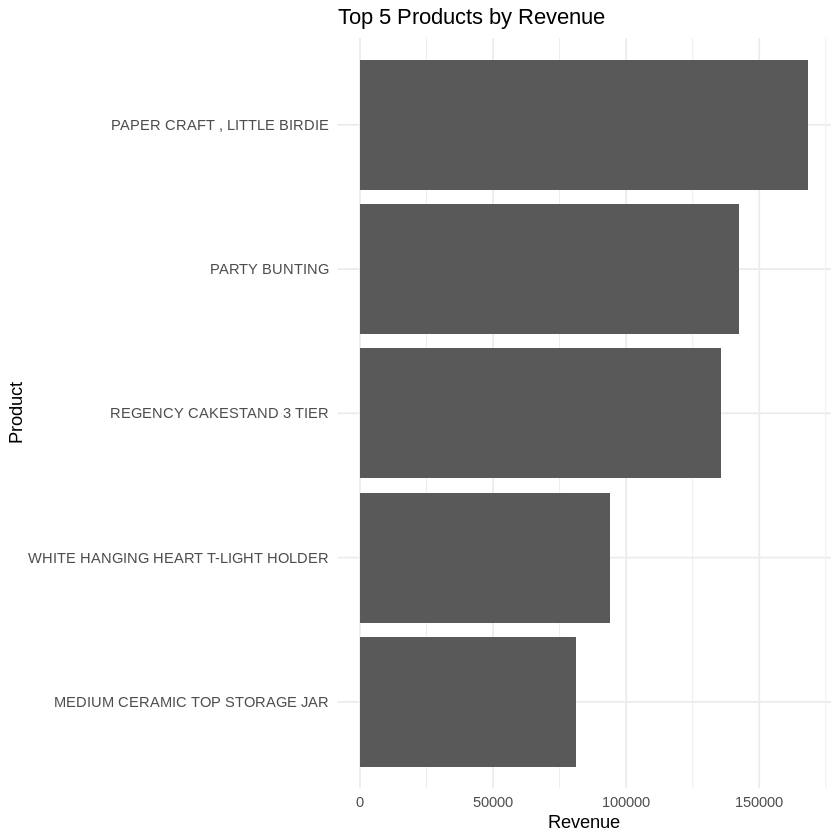

In [101]:
ggplot(
  top_products,
  aes(
    x = reorder(Description, Total_Revenue),
    y = Total_Revenue
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 5 Products by Revenue",
    x = "Product",
    y = "Revenue"
  ) +
  theme_minimal()

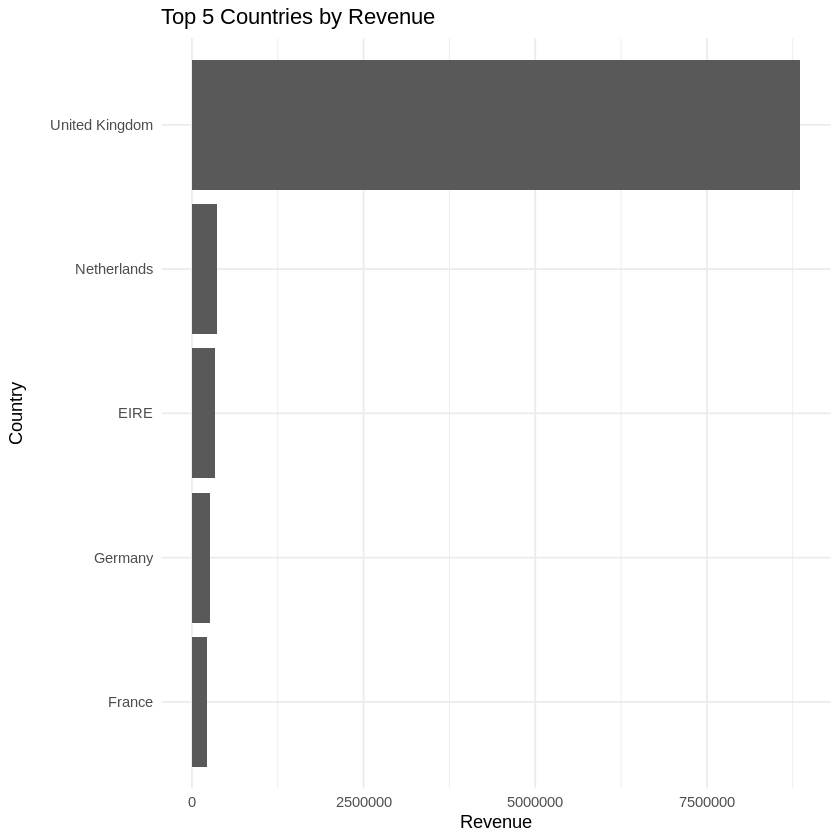

In [102]:
ggplot(
  top_countries,
  aes(
    x = reorder(Country, Total_Revenue),
    y = Total_Revenue
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 5 Countries by Revenue",
    x = "Country",
    y = "Revenue"
  ) +
  theme_minimal()

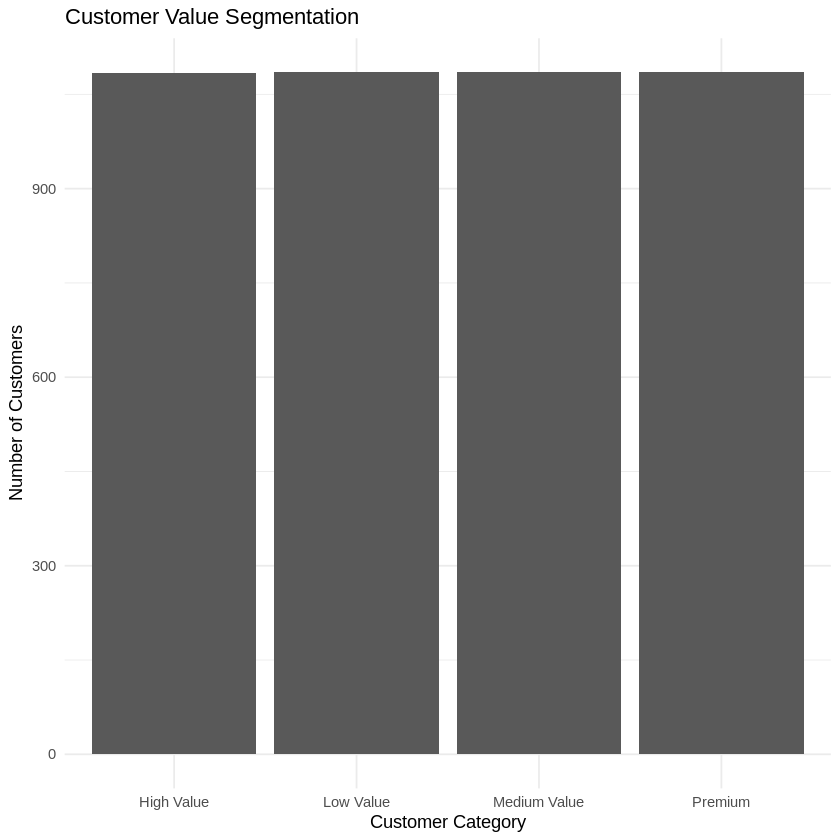

In [103]:
ggplot(
  customer_segments,
  aes(
    x = Customer_Category,
    y = n
  )
) +
  geom_col() +
  labs(
    title = "Customer Value Segmentation",
    x = "Customer Category",
    y = "Number of Customers"
  ) +
  theme_minimal()